# Real state price predictor:
The task is to predict median house values in Californian districts, given a number of features from these districts.

In [96]:
# Basic libraries
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import scipy.stats as stats

# Obtaining data
import tarfile
import urllib.request
from pathlib import Path

# Machine learning framework
import sklearn.model_selection
import sklearn.preprocessing
import sklearn.compose
import sklearn.pipeline
import sklearn.metrics

## Getting the data
The California housing dataset was derived from the 1990 U.S. Census, and it is available in many places, including on [Kaggle](https://www.kaggle.com/datasets/camnugent/california-housing-prices). Here, we will download it from an open GitHub repository.

In [61]:
# Downloading the data from an open github repository
url = "https://github.com/ageron/data/raw/main/housing.tgz"
tarball_path = Path("datasets/housing.tgz")
urllib.request.urlretrieve(url, tarball_path)

(WindowsPath('datasets/housing.tgz'),
 <http.client.HTTPMessage at 0x1fca962d8b0>)

In [62]:
# Decompressing the tarball
with tarfile.open(tarball_path) as housing_tar:
    housing_tar.extractall(path="datasets")

C:\Users\ncesc\AppData\Local\Temp\ipykernel_29472\1274519656.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tar.extractall(path="datasets")


In [63]:
# Getting the data
housing = pd.read_csv('datasets/housing/housing.csv')
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**Basic exploration of the data**

In [64]:
# Basic information
print(housing.info(),
      housing.shape,
      sep="\n\n"
)

# Overview of the data
pd.concat([housing.head(), housing.tail()])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


**Understanding missing observations**

In [65]:
# Determining the number of missing values in each feature
print(housing.isna().sum(axis=0),
      housing.isna().sum(axis=0) / len(housing),
      sep="\n\n"
)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        0.010029
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64


<Axes: >

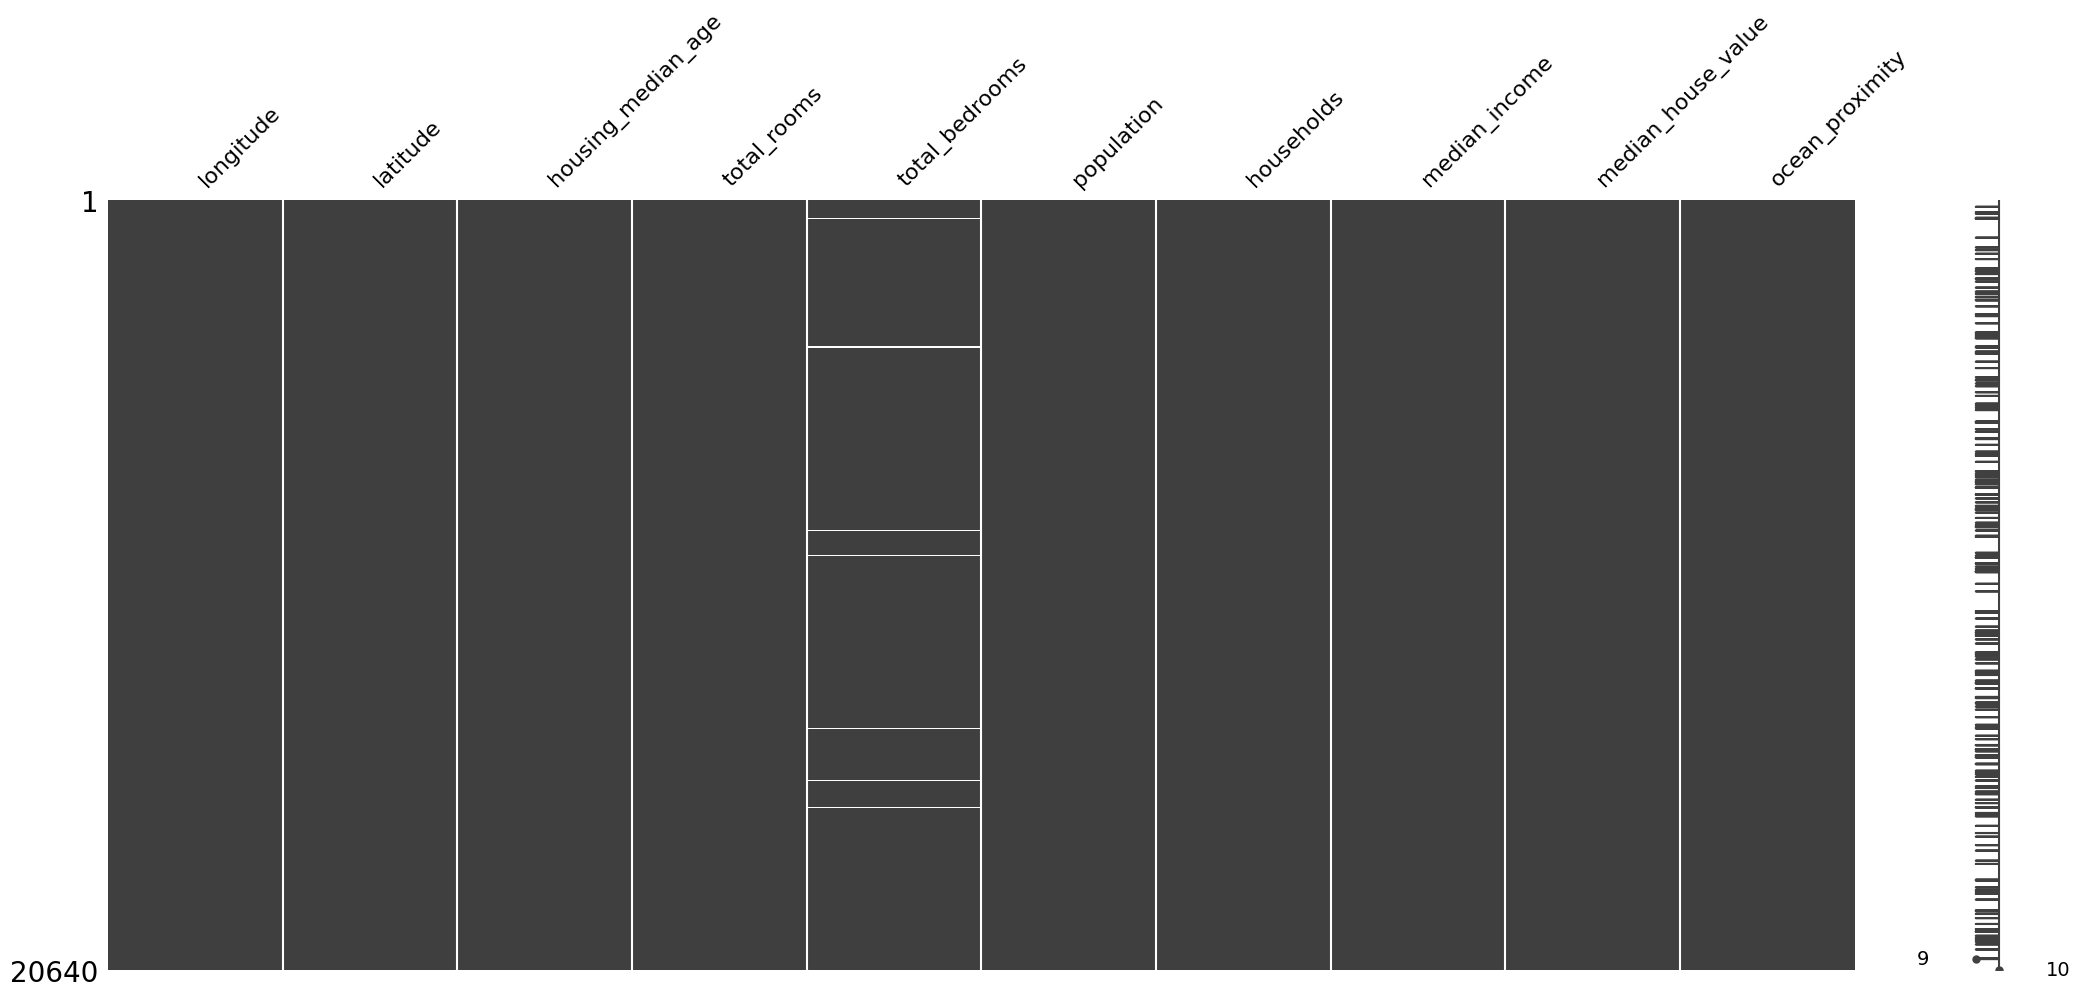

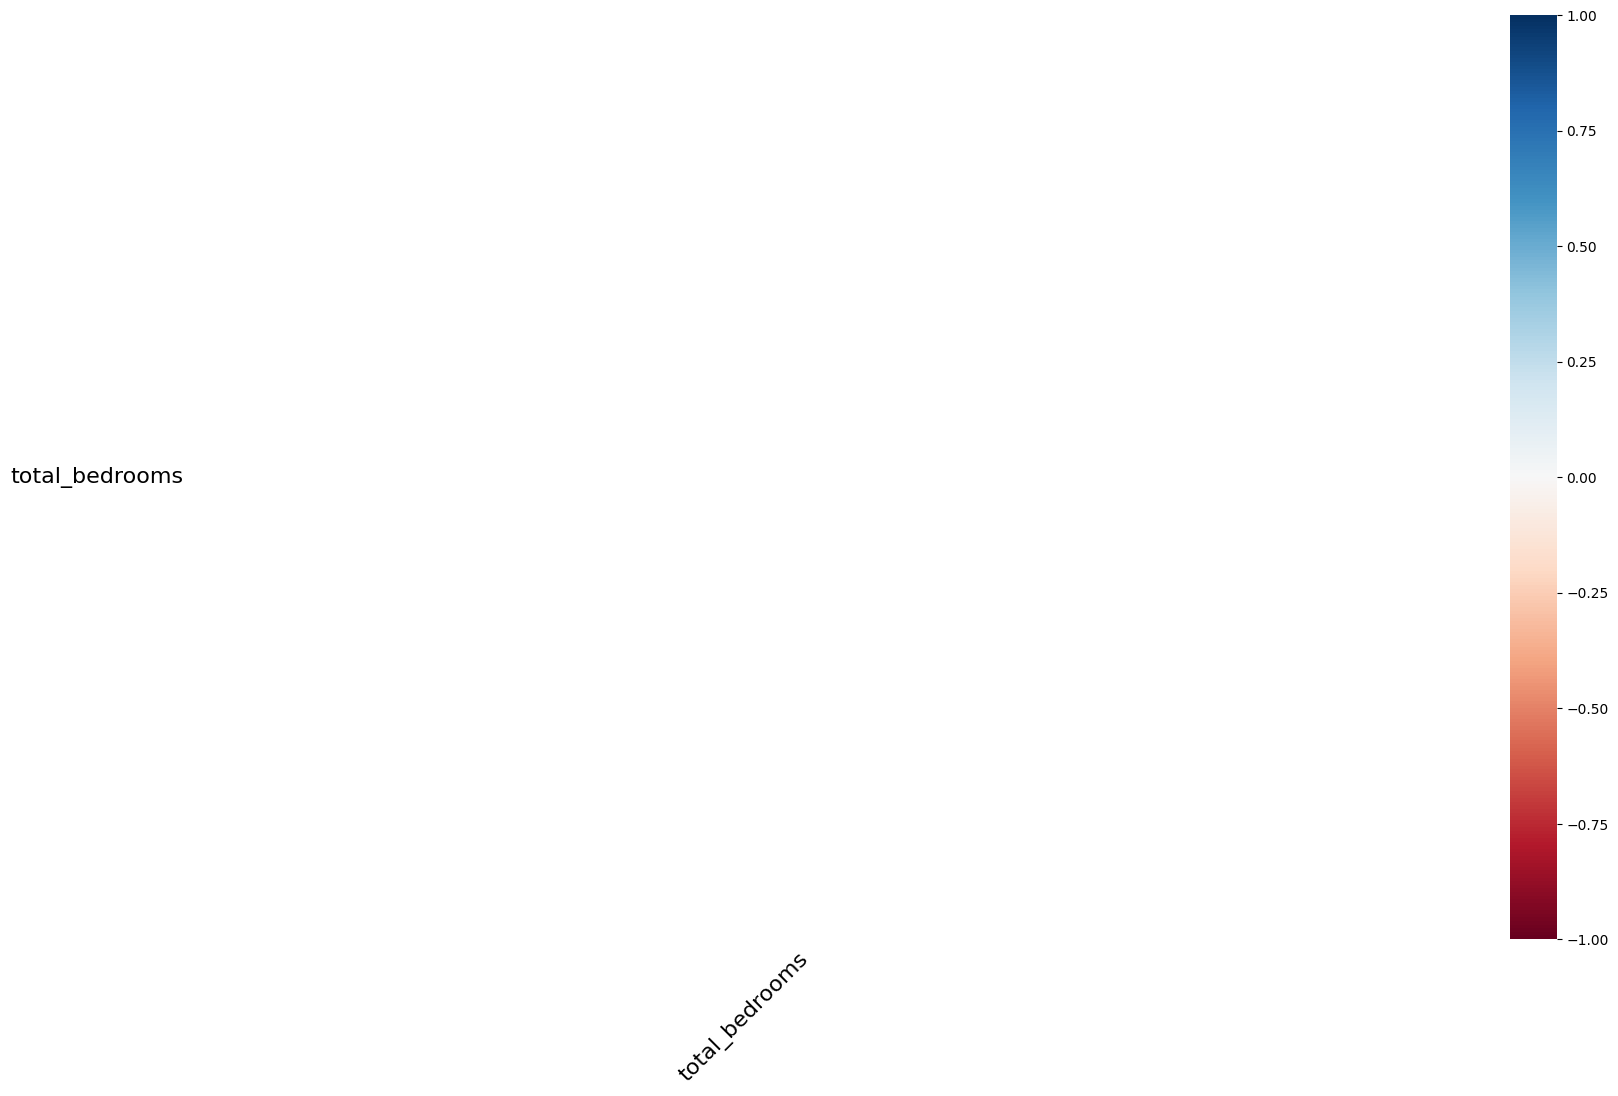

In [66]:
# Understanding if the missing observations depict a pattern or correlations
missingno.matrix(housing)
missingno.heatmap(housing)

# From both plots we can see that there is no particular pattern in the missing values and that the only feature with missing values is the total_bedrooms.

**Fixing data types**<br>
Important step for reducing memory usage and improving performance.

In [67]:
# Determining which columns are really float types
integers = np.where(np.sum(housing.iloc[:, np.where(housing.dtypes != 'object')[0]] % 1, axis=0) == 0)[0]

# Correcting the data types
housing.columns[integers]
# For integers
for col in housing.columns[integers]:
    housing[col] = housing[col].astype('int64', errors='ignore')

# For categorical
print(housing['ocean_proximity'].value_counts())
housing['ocean_proximity'] = housing['ocean_proximity'].astype('category')

print(housing.info())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  int64   
 3   total_rooms         20640 non-null  int64   
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  int64   
 6   households          20640 non-null  int64   
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  int64   
 9   ocean_proximity     20640 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB
None


## Exploratory data analysis (EDA)

In [ ]:
# For numerical features
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
# For categorical features
housing.describe(exclude='number')

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


['housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_house_value']

In [95]:
# Evaluating skewness and kurtosis
pd.DataFrame(np.vstack([stats.skew(housing.select_dtypes(include=['int64', 'float64']), axis=0),
                        stats.kurtosis(housing.select_dtypes(include=['int64', 'float64']), axis=0)]).T,
    columns=['Skewness', 'Kurtosis'], index = list(housing.columns[np.where(housing.dtypes != 'category')]))


,Skewness,Kurtosis
longitude,-0.297780,-1.330121
latitude,0.465919,-1.117780
housing_median_age,0.060326,-0.800726
total_rooms,4.147042,32.622732
total_bedrooms,NaN,NaN
population,4.935500,73.535009
households,3.410190,22.052354
median_income,1.646537,4.951034
median_house_value,0.977692,0.327500


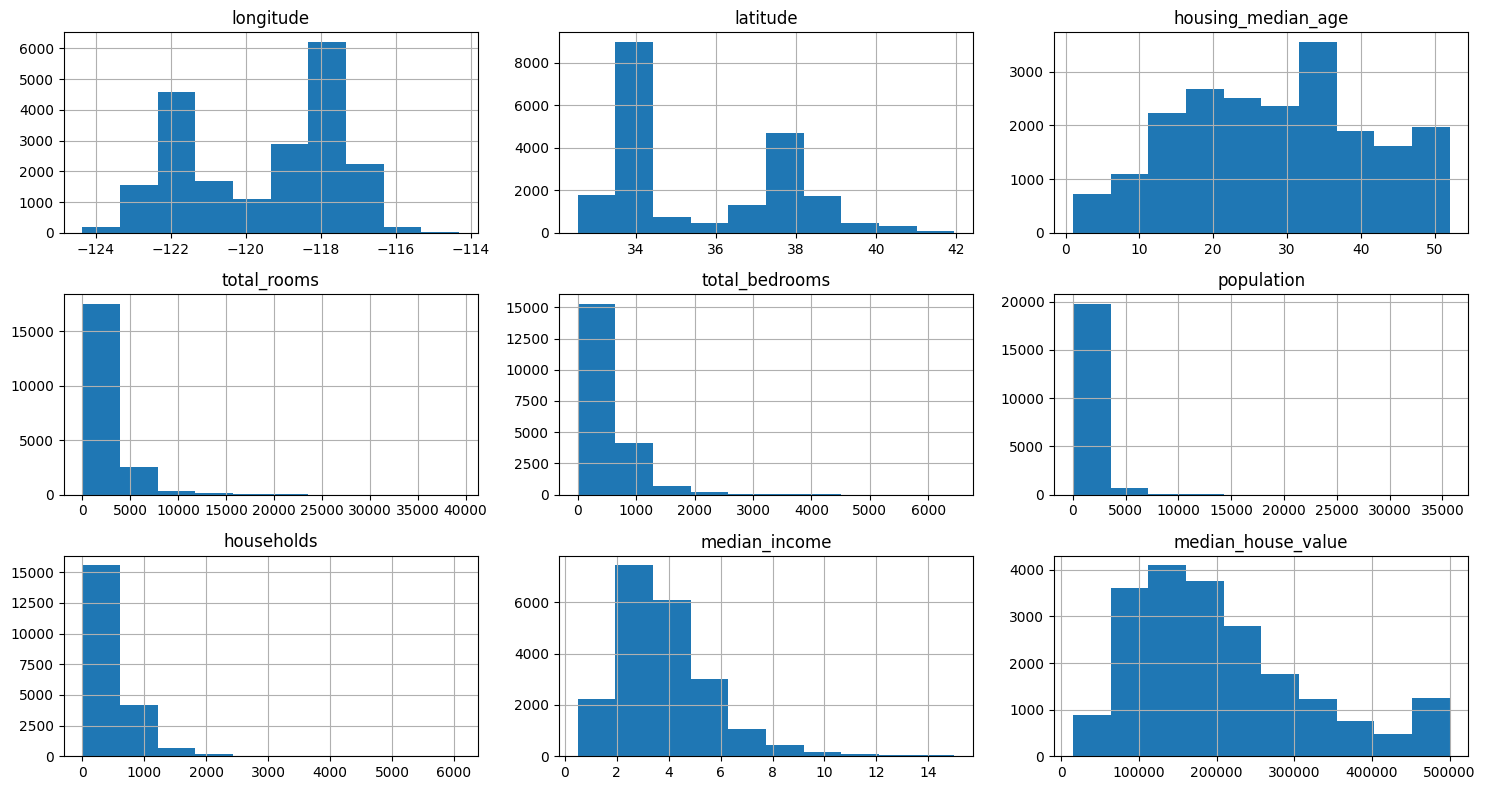

In [73]:
housing.hist(grid=True, figsize=(15,8))
plt.tight_layout()
plt.show()

<Figure size 1600x500 with 0 Axes>

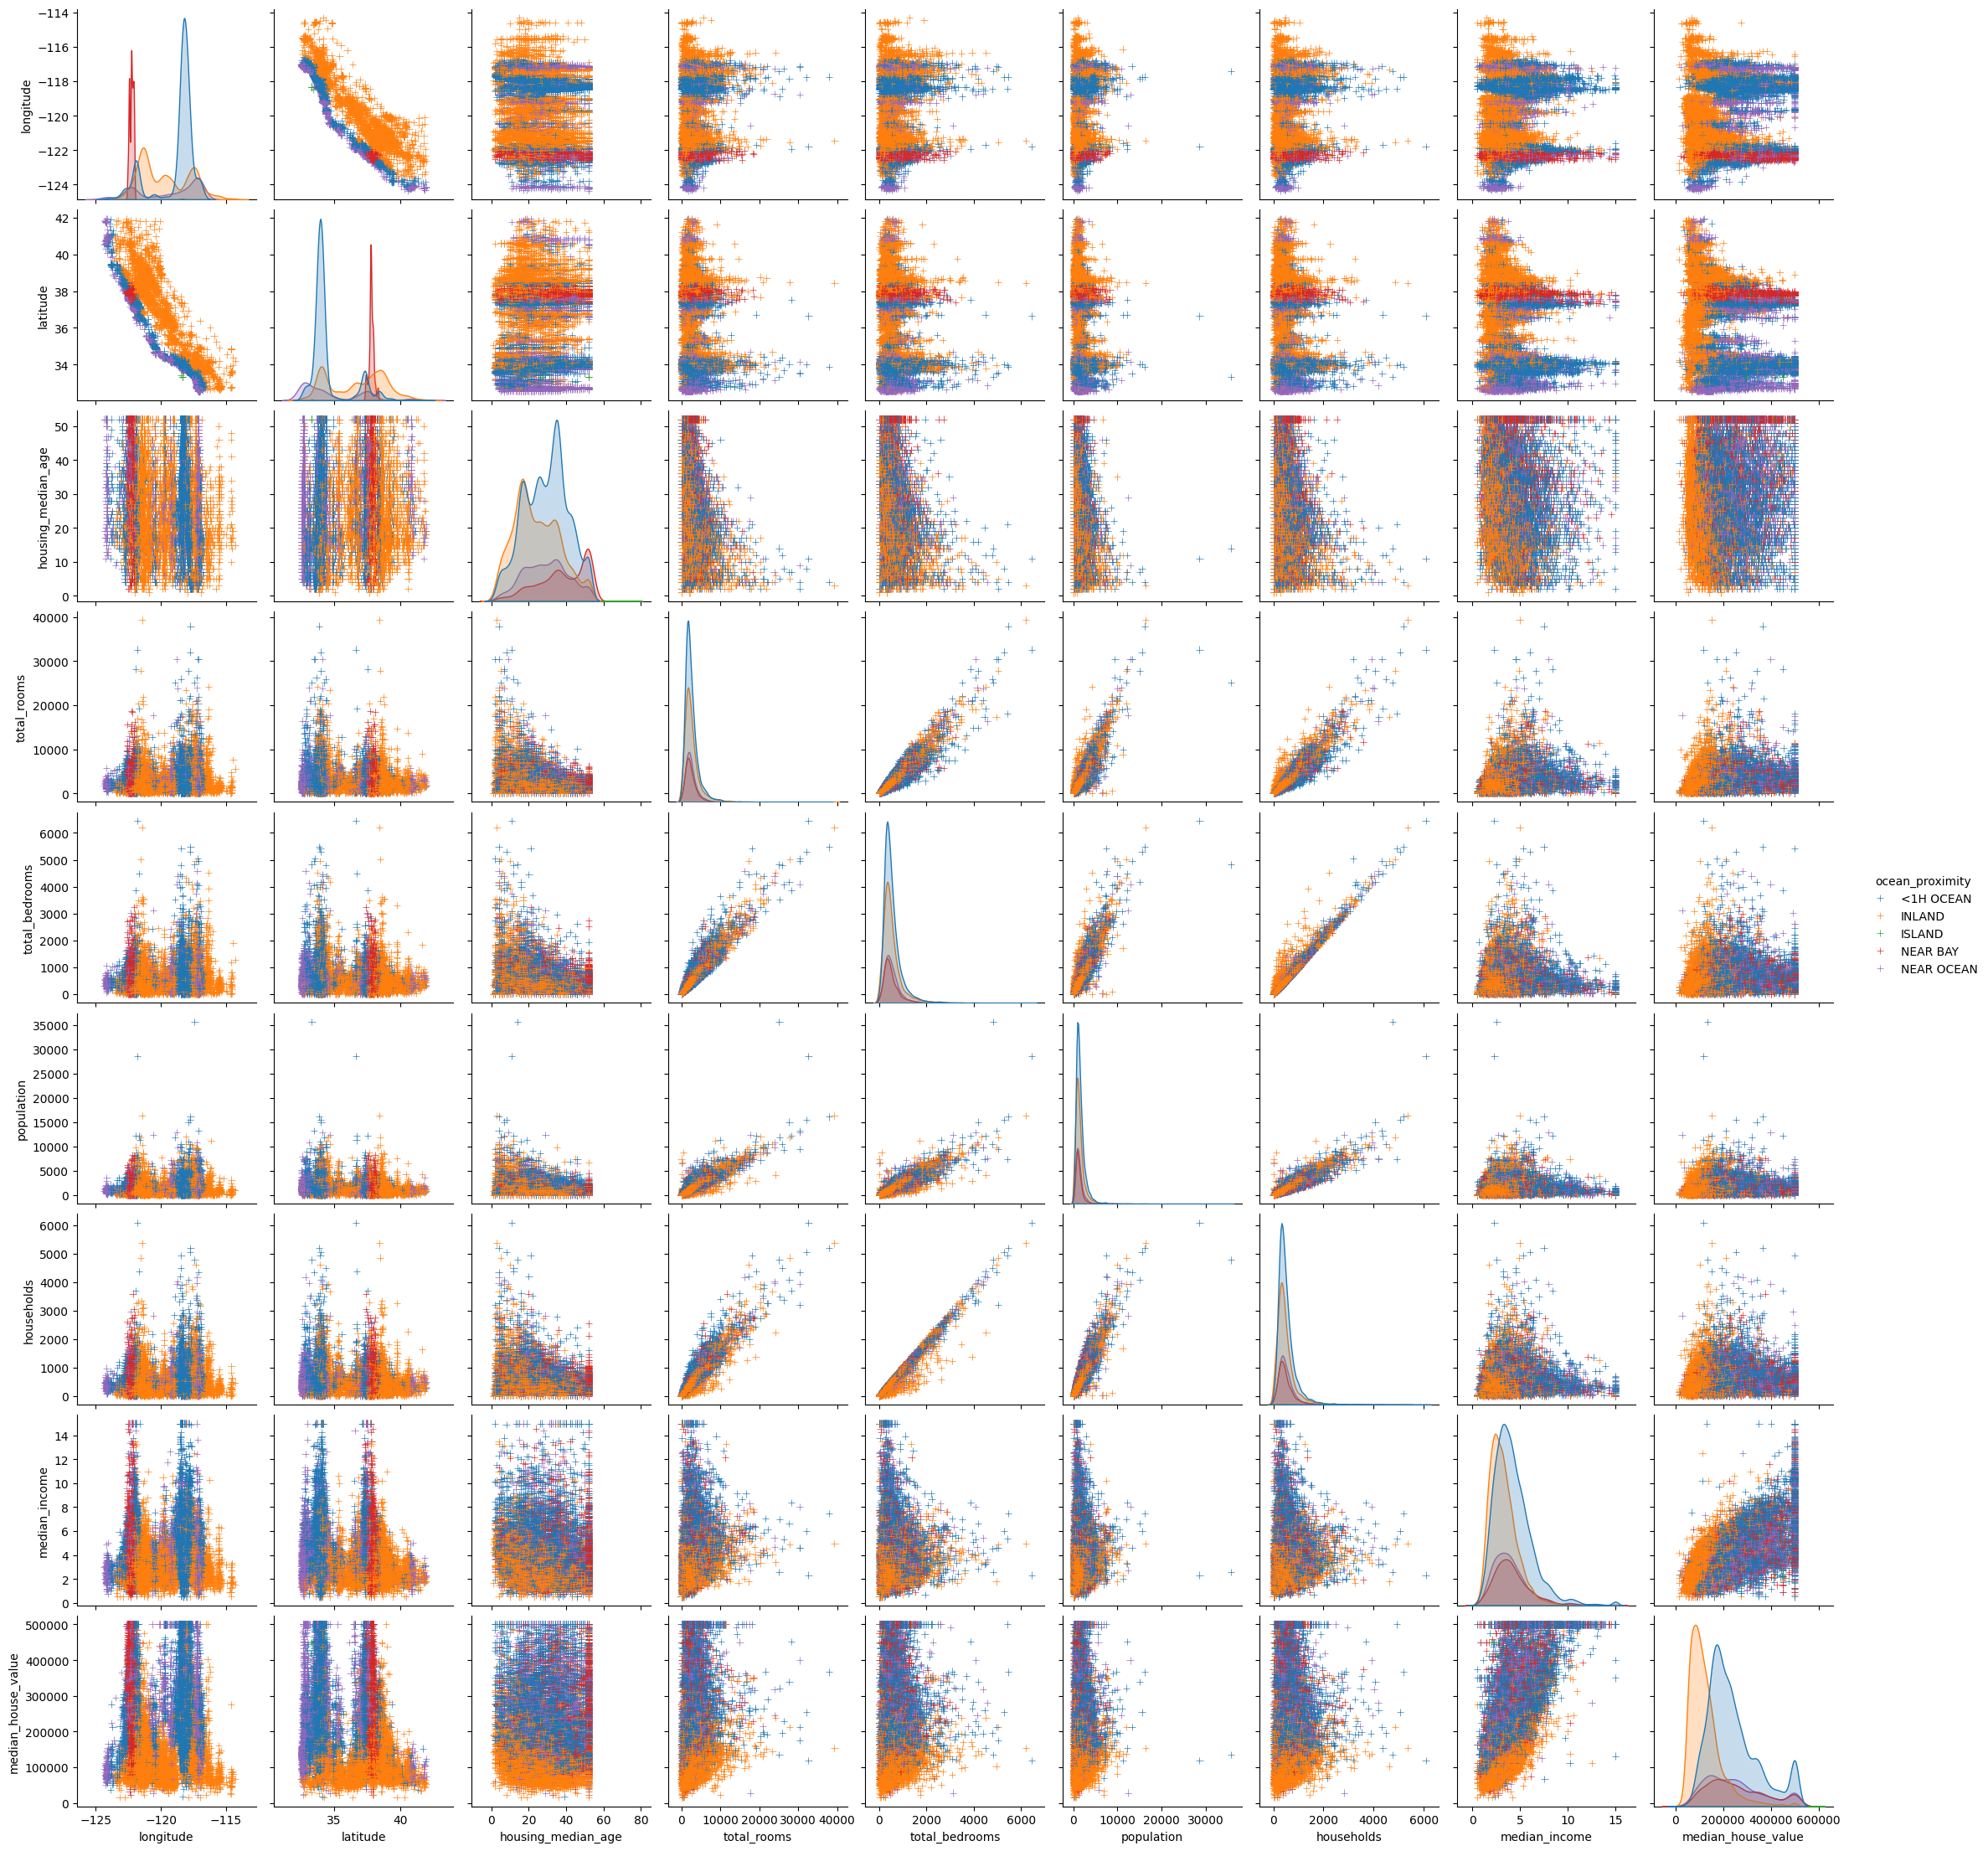

In [ ]:
# Pairplot to visualize relationships between features
plt.figure(figsize = (16, 5))
sns.pairplot(housing, hue='ocean_proximity', diag_kind='kde', markers='+')
plt.show()

From the histograms, we can see that most of the numerical features have skewed distributions. We will need to address this later when we prepare the data for machine learning algorithms. Despite the skewness, there are no extreme outliers in the numerical features as most of the continuous variable were capped during data collection.

From the pairplot, we can see that there are some relationships between features. For example, there is a positive correlation between median_income and median_house_value. There are also some clusters of data points that correspond to different ocean_proximity categories. This suggests that ocean_proximity may be an important feature for predicting median_house_value.

## Preparing the data for machine learning algorithms

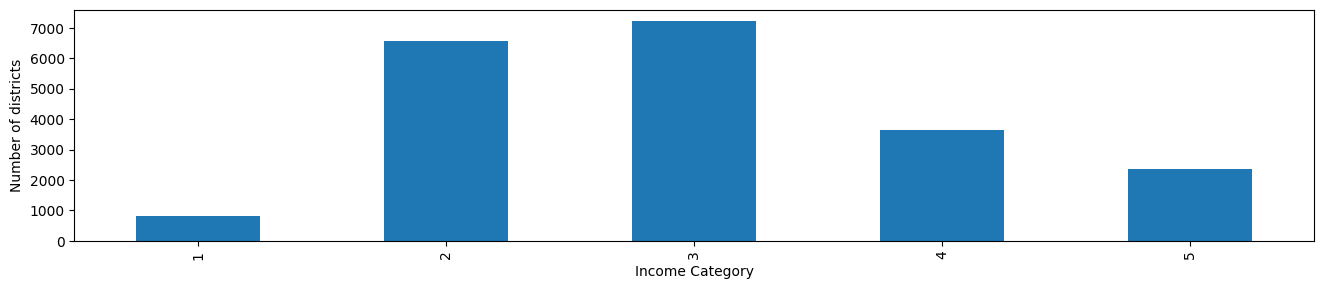

In [117]:
# Creating additional features based on the assumption that the median income is an attribute that allows to stratify the data
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5], ordered=True)

plt.figure(figsize= (16, 3))
housing['income_cat'].value_counts(sort=False).plot(kind='bar')
plt.xlabel('Income Category')
plt.ylabel('Number of districts')
plt.show()

In [ ]:
# Setting a random seed for reproducibility
SEED = 42

# Train test split using the base 80-20 pertition
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(housing.drop('median_house_value', axis=1),
                                                                            housing['median_house_value'],
                                                                            test_size=0.2,
                                                                            random_state=SEED,
                                                                            stratify=housing['income_cat'])
# Checking the shape of the splits
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape, sep="\n")

(16512, 10)
(4128, 10)
(16512,)
(4128,)


In [130]:
# Verifying the income category proportions in the train and test sets
print(pd.concat([x_train['income_cat'].value_counts(normalize=True).sort_index(),
                 x_test['income_cat'].value_counts(normalize=True).sort_index()],
                axis=1, keys=['Train', 'Test']))

# Removing the income_cat attribute so the data is back to its original state
for dataset in (x_train, x_test):
    dataset.drop('income_cat', axis=1, inplace=True)

               Train      Test
income_cat                    
1           0.039789  0.039971
2           0.318859  0.318798
3           0.350594  0.350533
4           0.176296  0.176357
5           0.114462  0.114341


**In depth exploratory data analysis**

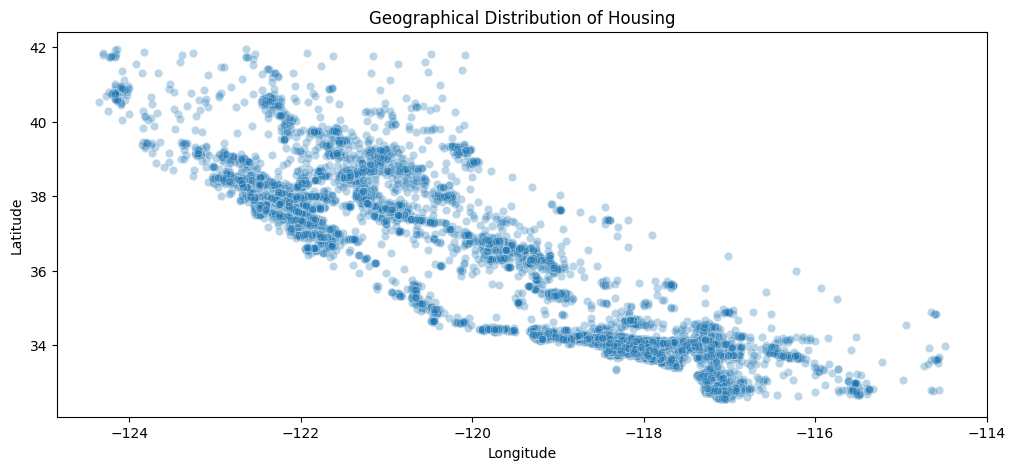

In [148]:
# Understanding geographical data
plt.figure(figsize=(12, 5))
sns.scatterplot(data=x_train, x='longitude', y='latitude', alpha=0.3)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Housing')
plt.show()

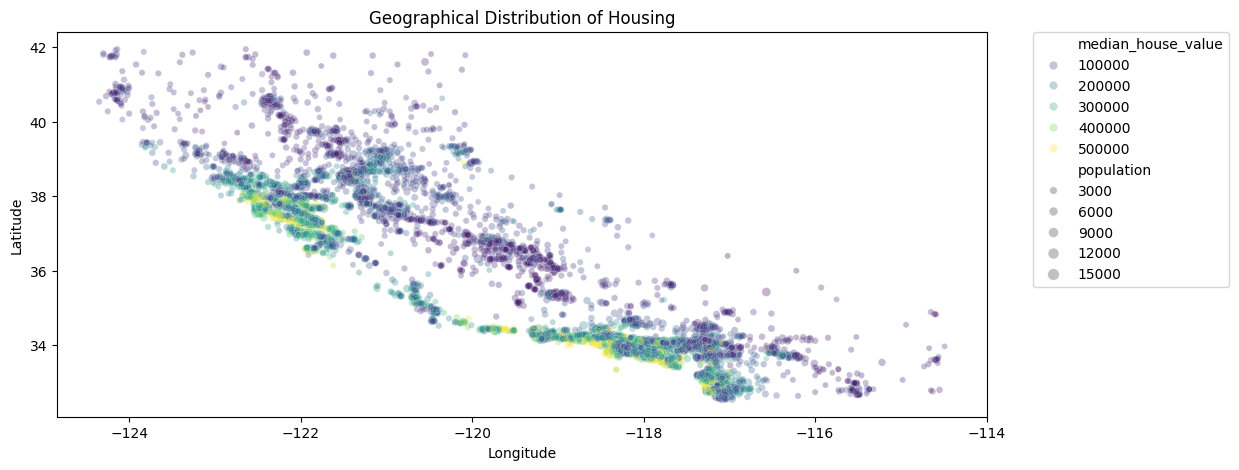

In [151]:
# Understanding geographical data
plt.figure(figsize=(12, 5))
sns.scatterplot(data=x_train, x='longitude', y='latitude', size='population', hue=y_train, alpha=0.3, palette='viridis')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Housing')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

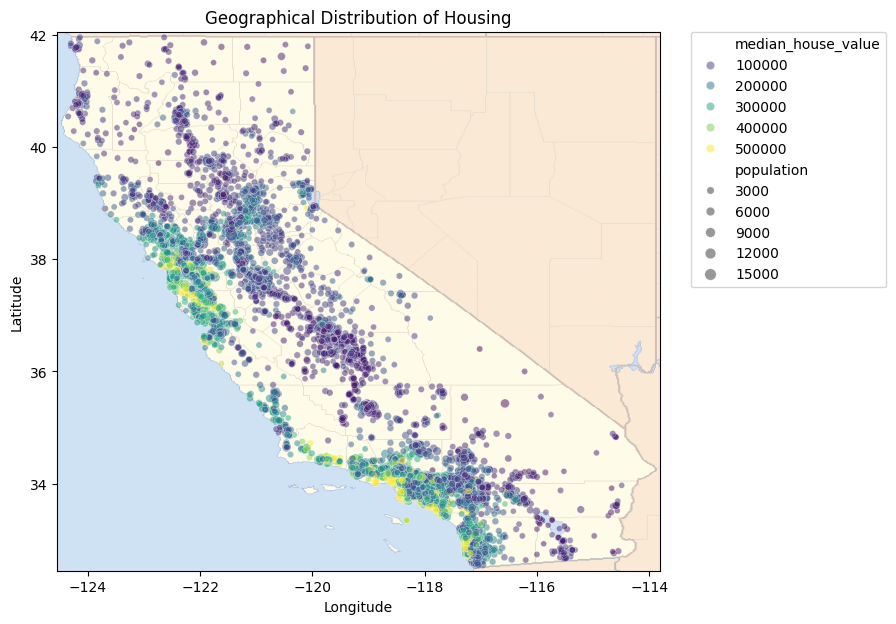

In [170]:
# Obtaining the base layout
url = "https://github.com/ageron/handson-ml3/raw/main/images/end_to_end_project/"
filename = "california.png"

Path("images").mkdir(parents=True, exist_ok=True)
urllib.request.urlretrieve(url=url + filename, filename = "images/" + filename)

# Plotting the geographical data
plt.figure(figsize=(10, 7))
sns.scatterplot(data=x_train, x='longitude', y='latitude', size='population', hue=y_train, alpha=0.5, palette='viridis')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Housing')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

california_img = plt.imread("images/" + filename)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5)
plt.show()

From it we can see that there is a clear relationship between longitude and latitude and the median_house_value. This suggests that location is an important factor in determining house prices. We can also see that there are some areas with high population density that have lower median_house_value, which may indicate that these areas are less desirable to live in.

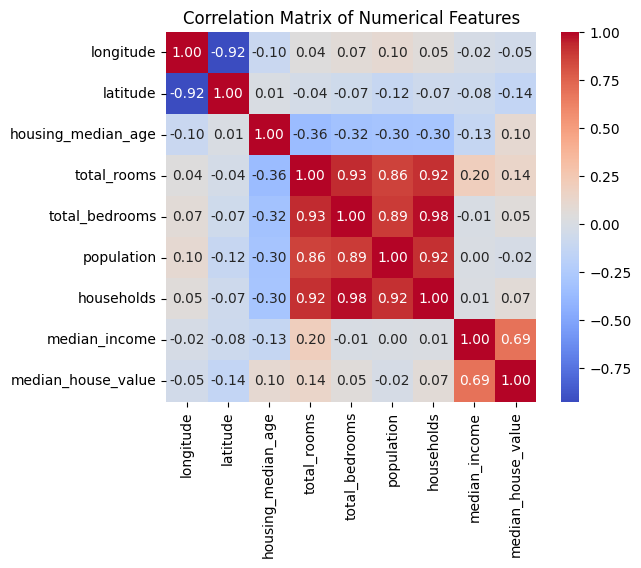

In [159]:
# Evaluating correlations between numerical features
corr_matrix = pd.concat([x_train.loc[:, x_train.dtypes != 'category'], y_train], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

From the correlation matrix, we can see that median_income has the highest positive correlation with median_house_value (0.69). This suggests that median_income is an important feature for predicting house prices. Other features with positive correlations include total_rooms (0.13), housing_median_age (0.11), and population (0.07). Features with negative correlations include longitude (-0.05) and latitude (-0.03). Overall, the correlation values indicate that there are some relationships between the features and the target variable, but they are not very strong.

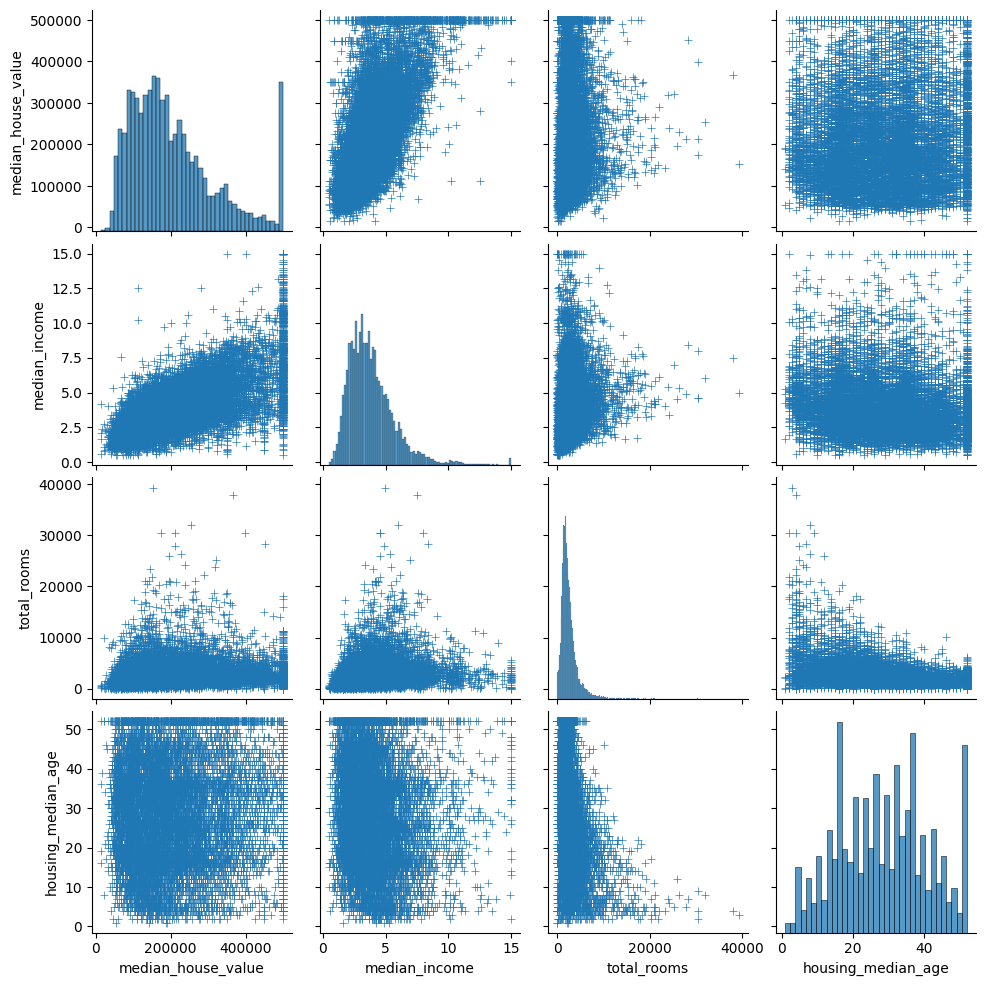

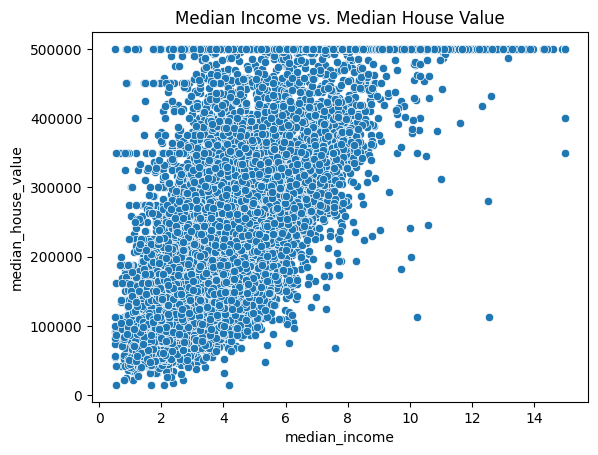

In [166]:
attributes = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']

# Evaluating the most promissing attributes
sns.pairplot(data=pd.concat([x_train.loc[:, x_train.dtypes != 'category'], y_train], axis=1), vars=attributes, markers='+')
plt.show()

# Zooming in on the most promising attribute
sns.scatterplot(data=pd.concat([x_train.loc[:, x_train.dtypes != 'category'], y_train], axis=1), x='median_income', y='median_house_value', markers='+')
plt.title('Median Income vs. Median House Value')
plt.show()